# Import Essential Libraries

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [2]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import r2_score, explained_variance_score, mean_absolute_error, mean_squared_error
from math import sqrt


import warnings
warnings.simplefilter(action='ignore', category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning) 
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError, MeanAbsoluteError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam, AdamW
from keras.regularizers import l2
from tensorflow.keras.models import load_model

2025-06-19 22:26:11.033995: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750371971.228890      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750371971.288003      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Load Data

In [4]:
file_path = "PRSA_Data_Changping_20130301-20170228.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "sid321axn/beijing-multisite-airquality-data-set",
  file_path,
)

print(df.shape)
df.head()

(35064, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping


In [5]:
# Initialize an empty DataFrame
df = pd.DataFrame()

dataset_dir = "/kaggle/input/"

# Loop through all CSV files in the directory
for dirname, _, filenames in os.walk(dataset_dir):
    for filename in filenames:
        if filename.endswith(".csv"):  # Ensure it's a CSV file
            file_path = os.path.join(dirname, filename)
            print("Loading:", file_path)

            # Load dataset
            df_AQI1 = pd.read_csv(file_path, encoding="utf-8")

            # Append to main DataFrame
            df = pd.concat([df, df_AQI1], ignore_index=True)

# Display final DataFrame shape
print("Aggregated Dataset Shape:", df.shape)
df.head()

Loading: /kaggle/input/PRSA_Data_Guanyuan_20130301-20170228.csv
Loading: /kaggle/input/PRSA_Data_Aotizhongxin_20130301-20170228.csv
Loading: /kaggle/input/PRSA_Data_Wanliu_20130301-20170228.csv
Loading: /kaggle/input/PRSA_Data_Tiantan_20130301-20170228.csv
Loading: /kaggle/input/PRSA_Data_Wanshouxigong_20130301-20170228.csv
Loading: /kaggle/input/PRSA_Data_Nongzhanguan_20130301-20170228.csv
Loading: /kaggle/input/PRSA_Data_Shunyi_20130301-20170228.csv
Loading: /kaggle/input/PRSA_Data_Changping_20130301-20170228.csv
Loading: /kaggle/input/PRSA_Data_Dingling_20130301-20170228.csv
Loading: /kaggle/input/PRSA_Data_Huairou_20130301-20170228.csv
Loading: /kaggle/input/PRSA_Data_Gucheng_20130301-20170228.csv
Loading: /kaggle/input/PRSA_Data_Dongsi_20130301-20170228.csv
Aggregated Dataset Shape: (420768, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan
1,2,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan
2,3,2013,3,1,2,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan
3,4,2013,3,1,3,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan
4,5,2013,3,1,4,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


In [7]:
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


# Pre-processing

In [8]:
# DateTime Conversion & Set Index
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']].astype(str).agg(' '.join, axis=1), format='%Y %m %d %H')
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan,2013-03-01 00:00:00
1,2,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan,2013-03-01 01:00:00
2,3,2013,3,1,2,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan,2013-03-01 02:00:00
3,4,2013,3,1,3,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan,2013-03-01 04:00:00


In [9]:
# Aggregation dataset
aggregated_df = df.groupby('datetime').agg({
    'PM2.5': 'mean',
    'PM10': 'mean',
    'SO2': 'mean',
    'NO2': 'mean',
    'CO': 'mean',
    'O3': 'mean',
    'TEMP': 'mean',
    'PRES': 'mean',
    'DEWP': 'mean',
    'RAIN': 'mean',
    'WSPM': 'mean'
}).reset_index()

In [10]:
aggregated_df.head()

,datetime,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
0,2013-03-01 00:00:00,5.666667,7.916667,5.666667,12.600000,308.333333,75.416667,-0.916667,1022.766667,-19.900000,0.0,4.175000
1,2013-03-01 01:00:00,6.833333,9.833333,5.333333,13.111111,308.333333,75.750000,-1.216667,1023.191667,-19.916667,0.0,3.875000
2,2013-03-01 02:00:00,5.666667,7.250000,8.166667,12.900000,300.000000,66.000000,-1.591667,1023.325000,-21.008333,0.0,4.400000
3,2013-03-01 03:00:00,6.000000,9.250000,5.833333,12.400000,283.333333,75.333333,-1.891667,1024.208333,-21.833333,0.0,3.366667
4,2013-03-01 04:00:00,4.833333,6.916667,6.750000,14.000000,308.333333,66.333333,-2.283333,1024.866667,-21.625000,0.0,2.716667


In [11]:
data = aggregated_df.copy()

In [12]:
data = data.set_index('datetime')
print(data.shape)
data.head()

(35064, 11)


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
datetime,,,,,,,,,,,
2013-03-01 00:00:00,5.666667,7.916667,5.666667,12.600000,308.333333,75.416667,-0.916667,1022.766667,-19.900000,0.0,4.175000
2013-03-01 01:00:00,6.833333,9.833333,5.333333,13.111111,308.333333,75.750000,-1.216667,1023.191667,-19.916667,0.0,3.875000
2013-03-01 02:00:00,5.666667,7.250000,8.166667,12.900000,300.000000,66.000000,-1.591667,1023.325000,-21.008333,0.0,4.400000
2013-03-01 03:00:00,6.000000,9.250000,5.833333,12.400000,283.333333,75.333333,-1.891667,1024.208333,-21.833333,0.0,3.366667
2013-03-01 04:00:00,4.833333,6.916667,6.750000,14.000000,308.333333,66.333333,-2.283333,1024.866667,-21.625000,0.0,2.716667


In [13]:
# Null Values
data.isna().sum()

PM2.5     81
PM10      83
SO2       87
NO2       87
CO       204
O3       107
TEMP      18
PRES      18
DEWP      18
RAIN      18
WSPM      12
dtype: int64

In [14]:
# Set values as Nan
for i in data.columns:
    dt = data[i].astype(float) 
    if np.isnan(dt).all():
        continue
    
    Q1 = np.nanpercentile(dt, 25)
    Q3 = np.nanpercentile(dt, 75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR
    data.loc[(data[i] > upper) | (data[i] < lower), i] = np.nan

In [15]:
data = data.fillna(method='ffill')

In [16]:
data.isna().sum()

PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEWP     0
RAIN     0
WSPM     1
dtype: int64

In [17]:
data = data.drop('WSPM', axis=1)

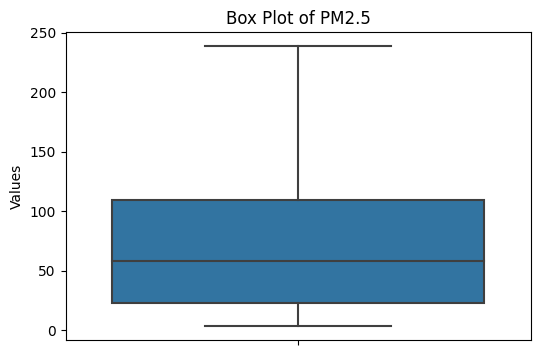

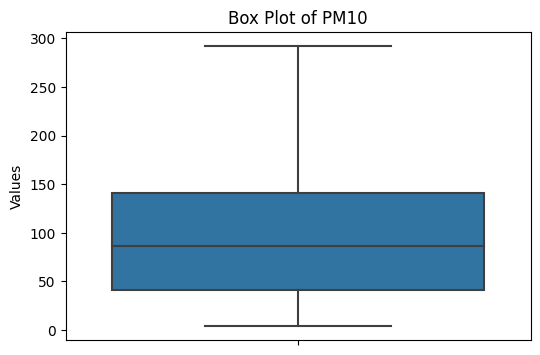

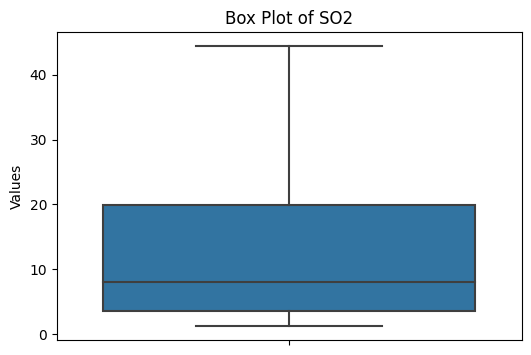

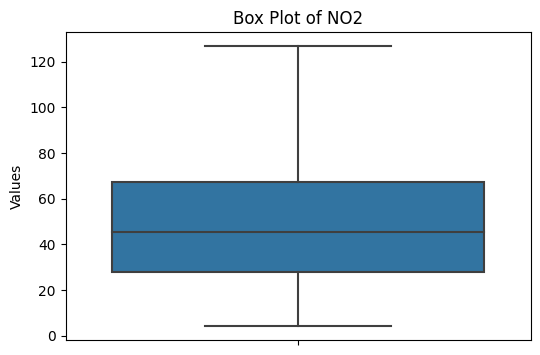

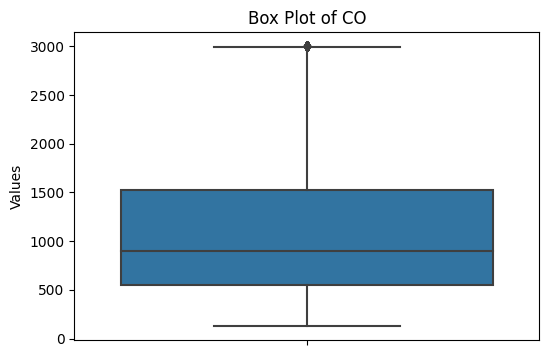

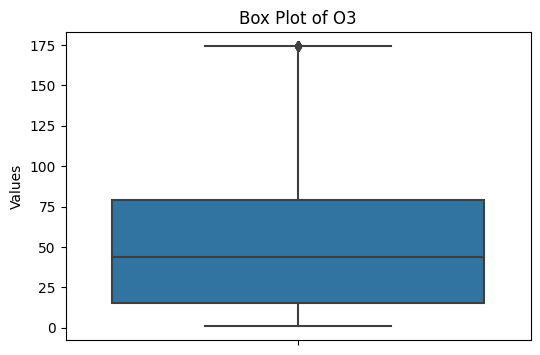

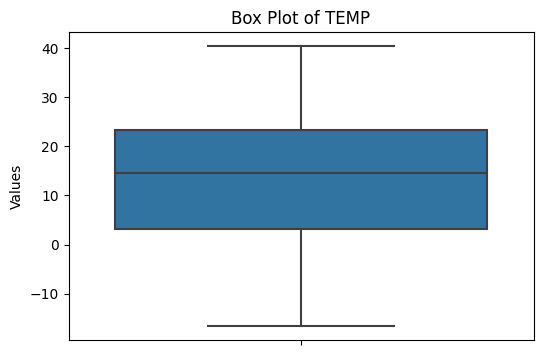

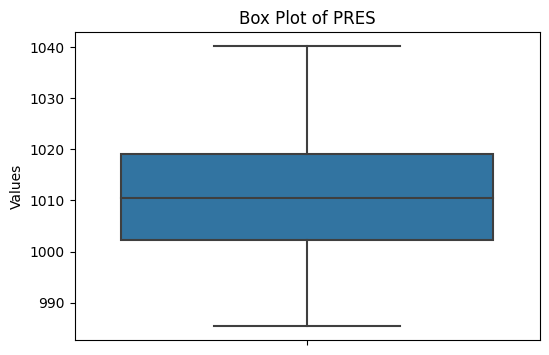

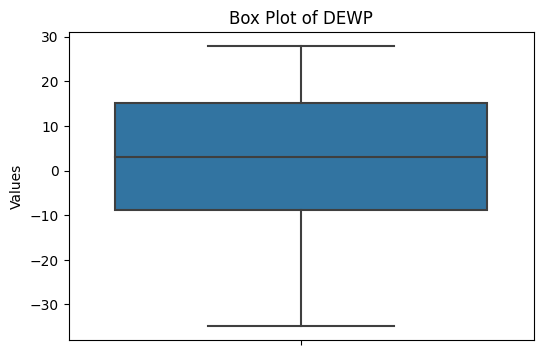

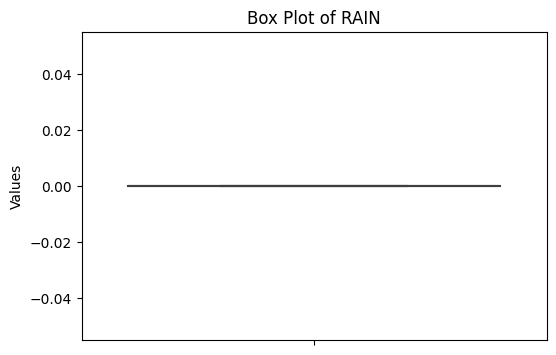

In [18]:
columns = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN']

# Loop through each column and generate a separate box plot
for col in columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=data[col])
    plt.title(f"Box Plot of {col}")
    plt.ylabel("Values")
    plt.show()

In [19]:
# Ensure no missing data
data = data.dropna()

# EDA

In [20]:
data.columns

Index(['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP',
       'RAIN'],
      dtype='object')

In [21]:
data.head()

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN
datetime,,,,,,,,,,
2013-03-01 00:00:00,5.666667,7.916667,5.666667,12.600000,308.333333,75.416667,-0.916667,1022.766667,-19.900000,0.0
2013-03-01 01:00:00,6.833333,9.833333,5.333333,13.111111,308.333333,75.750000,-1.216667,1023.191667,-19.916667,0.0
2013-03-01 02:00:00,5.666667,7.250000,8.166667,12.900000,300.000000,66.000000,-1.591667,1023.325000,-21.008333,0.0
2013-03-01 03:00:00,6.000000,9.250000,5.833333,12.400000,283.333333,75.333333,-1.891667,1024.208333,-21.833333,0.0
2013-03-01 04:00:00,4.833333,6.916667,6.750000,14.000000,308.333333,66.333333,-2.283333,1024.866667,-21.625000,0.0


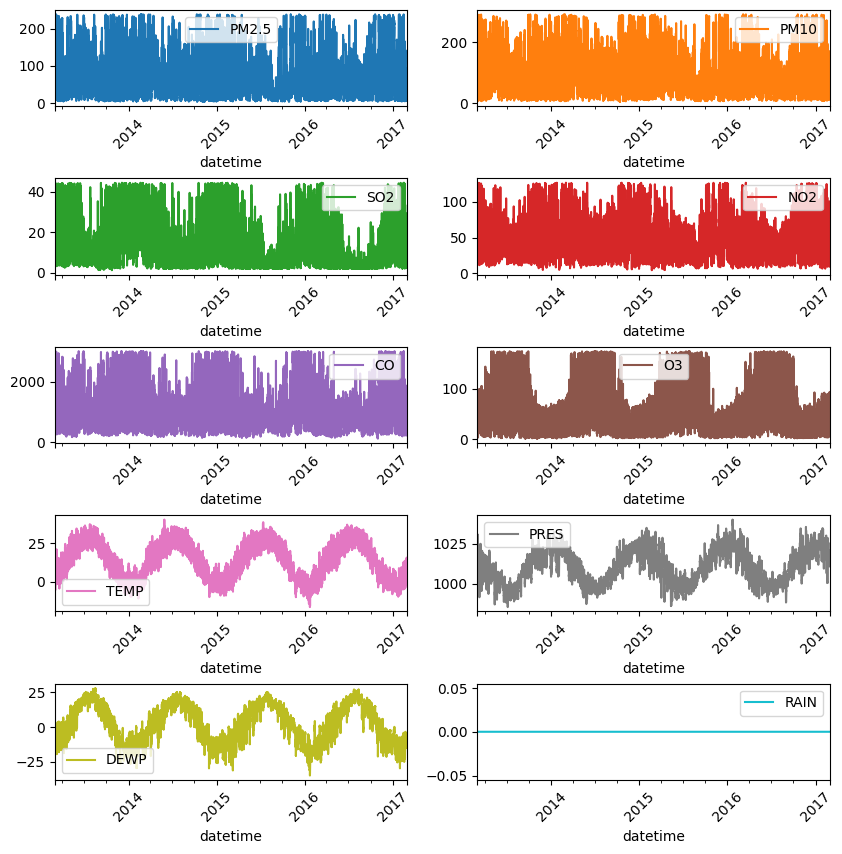

In [22]:
num_plots = len(data.columns)
nrows = (num_plots + 1) // 2 

fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(10,10))
axes = axes.flatten()[:num_plots] 

data.plot(subplots=True, ax=axes)
plt.subplots_adjust(hspace=0.75)

for ax in axes:  
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.show()

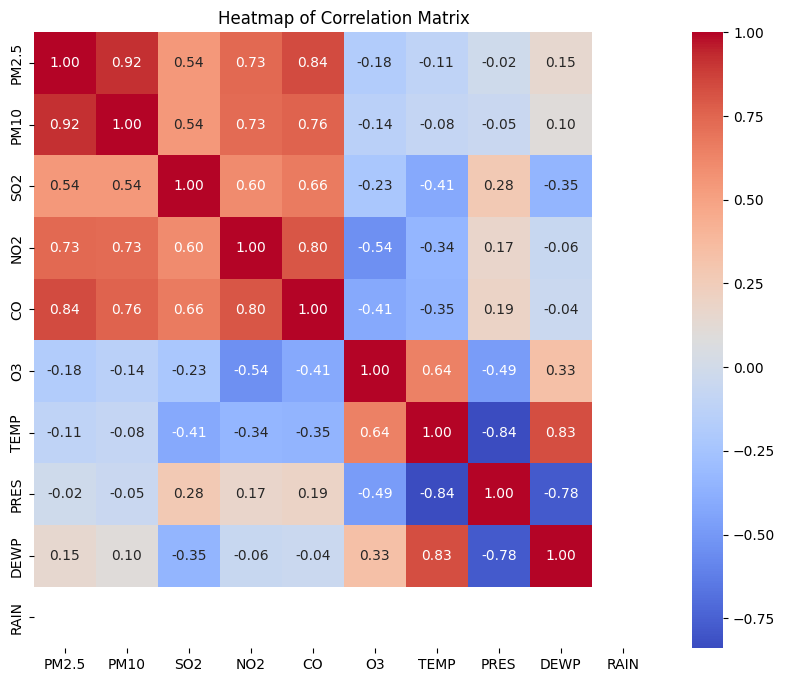

In [23]:
corr = data.corr(numeric_only=True)

# Create a heatmap using the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap of Correlation Matrix")

file_name = "correlation_matrix.png"
path = "/kaggle/working/"
full_path = os.path.join(path, file_name)
plt.savefig(full_path)
plt.show()

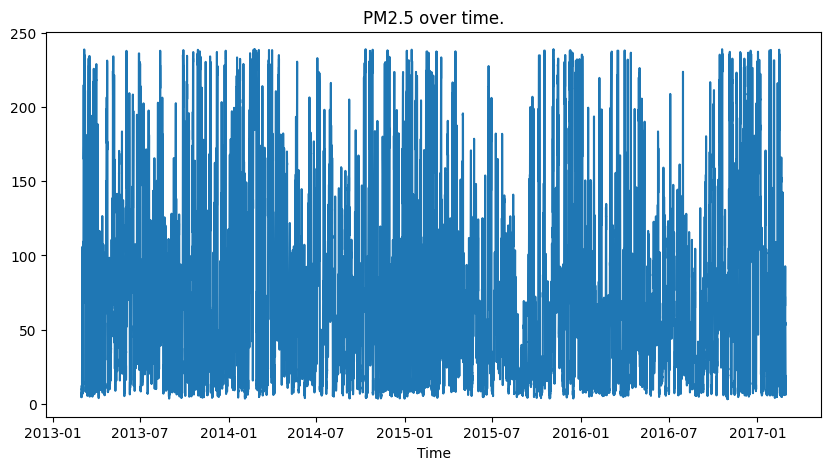

In [24]:
pm25 = data["PM2.5"]
plt.figure(figsize=(10,5))
plt.plot(pm25, label="PM2.5")
plt.title("PM2.5 over time.")
plt.xlabel("Time")

file_name = "PM2.5 over time.png"
path = "/kaggle/working/"
full_path = os.path.join(path, file_name)
plt.savefig(full_path)
plt.show()
plt.show()

# Data split

In [25]:
pm25_data = data['PM2.5']
features_data = data[['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP','RAIN']]

print(pm25_data)
print(features_data)

datetime
2013-03-01 00:00:00     5.666667
2013-03-01 01:00:00     6.833333
2013-03-01 02:00:00     5.666667
2013-03-01 03:00:00     6.000000
2013-03-01 04:00:00     4.833333
                         ...    
2017-02-28 19:00:00    16.083333
2017-02-28 20:00:00    19.000000
2017-02-28 21:00:00    15.666667
2017-02-28 22:00:00    13.666667
2017-02-28 23:00:00    15.000000
Name: PM2.5, Length: 35064, dtype: float64
                          PM10       SO2        NO2          CO         O3  \
datetime                                                                     
2013-03-01 00:00:00   7.916667  5.666667  12.600000  308.333333  75.416667   
2013-03-01 01:00:00   9.833333  5.333333  13.111111  308.333333  75.750000   
2013-03-01 02:00:00   7.250000  8.166667  12.900000  300.000000  66.000000   
2013-03-01 03:00:00   9.250000  5.833333  12.400000  283.333333  75.333333   
2013-03-01 04:00:00   6.916667  6.750000  14.000000  308.333333  66.333333   
...                        ...       ..

In [26]:
def new_data_to_X_y(features_df, target_series, window_size=24):
    # Convert features to numpy array
    features_np = features_df.to_numpy()
    target_np = target_series.to_numpy()
    X = []
    y = []
    
    for i in range(len(features_np) - window_size):
        X.append(features_np[i:i+window_size])
        y.append(target_np[i+window_size])
    
    return np.array(X), np.array(y)

In [27]:
WINDOW_SIZE = 24
X, y = new_data_to_X_y(features_data, pm25_data, WINDOW_SIZE)

print(f"X shape: {X.shape}") # (n_samples, window_size, n_features)
print(f"y shape: {y.shape}")

X shape: (35040, 24, 9)
y shape: (35040,)


In [28]:
train_size = int(len(X) * 0.6)
val_size = int(len(X) * 0.2)
test_size = len(X) - train_size - val_size  

# Correct indexing for the splits
X_train1 = X[:train_size]
X_val1 = X[train_size:train_size+val_size]
X_test1 = X[train_size+val_size:]

y_train1 = y[:train_size]
y_val1 = y[train_size:train_size+val_size]
y_test1 = y[train_size+val_size:]

In [29]:
print(f'Shape of X_train: {X_train1.shape} ')
print(f'Shape of y_train: {y_train1.shape} ')
print(f'Shape of X_val: {X_val1.shape} ')
print(f'Shape of y_val: {y_val1.shape} ')
print(f'Shape of X_test: {X_test1.shape} ')
print(f'Shape of y_test: {y_test1.shape} ')

Shape of X_train: (21024, 24, 9) 
Shape of y_train: (21024,) 
Shape of X_val: (7008, 24, 9) 
Shape of y_val: (7008,) 
Shape of X_test: (7008, 24, 9) 
Shape of y_test: (7008,) 


# Model Training

## Bi-GRU Model

In [30]:
gru_model = Sequential()
gru_model.add(InputLayer(shape=(24, 9)))
gru_model.add(BatchNormalization())
gru_model.add(Bidirectional(GRU(64, return_sequences=True)))
gru_model.add(Dropout(0.3))
gru_model.add(Bidirectional(GRU(32)))
gru_model.add(Dropout(0.3))
gru_model.add(Dense(32, activation='relu'))
gru_model.add(BatchNormalization())
gru_model.add(Dense(16, activation='relu'))
gru_model.add(Dense(1, activation='linear'))

gru_model.summary()

I0000 00:00:1750371996.021680      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1750371996.022460      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ batch_normalization                  │ (None, 24, 9)               │              36 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 24, 128)             │          28,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 64)                  │          31,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 62,693 (244.89 KB)

 Trainable params: 62,611 (244.57 KB)

 Non-trainable params: 82 (328.00 B)

In [31]:
cp_gru = ModelCheckpoint('/kaggle/working/gru_model.keras', save_best_only=True)

gru_model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), 
               metrics=[MeanAbsoluteError()])

In [32]:
history = gru_model.fit(
    X_train1, y_train1,
    validation_data=(X_val1, y_val1),
    epochs=30,
    callbacks=[cp_gru]
)

Epoch 1/30


I0000 00:00:1750372004.459335      65 cuda_dnn.cc:529] Loaded cuDNN version 90300


657/657 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9621.1914 - mean_absolute_error: 76.7286 - val_loss: 7347.2671 - val_mean_absolute_error: 63.2580
Epoch 2/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 7564.1260 - mean_absolute_error: 68.7515 - val_loss: 4986.2017 - val_mean_absolute_error: 53.0494
Epoch 3/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 5159.3799 - mean_absolute_error: 57.5755 - val_loss: 2891.4355 - val_mean_absolute_error: 41.1149
Epoch 4/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 2941.2876 - mean_absolute_error: 43.1003 - val_loss: 1407.8318 - val_mean_absolute_error: 28.6844
Epoch 5/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 1523.9323 - mean_absolute_error: 30.4251 - val_loss: 645.7980 - val_mean_absolute_error: 18.6161
Epoch 6/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 912.8171 - mean_absolute_error: 22.8624 - val_loss: 434.3015 - val_mean_absolute_error: 14.7503
Epoch 7/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss

In [33]:
gru_model = load_model('/kaggle/working/gru_model.keras')

## Bi-GRU Model Evaluation

In [34]:
train_result = gru_model.predict(X_train1)

# Calculate metrics
mse = mean_squared_error(y_train1, train_result)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train1, train_result)
r2 = r2_score(y_train1, train_result)

# Print the results
print("Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (Accuracy): {r2:.4f}")

657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
Evaluation Metrics:
Mean Absolute Error (MAE): 10.0375
Mean Squared Error (MSE): 198.4888
Root Mean Squared Error (RMSE): 14.0886
R-squared (Accuracy): 0.9498


In [35]:
val_result = gru_model.predict(X_val1)

# Calculate metrics
mse = mean_squared_error(y_val1, val_result)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val1, val_result)
r2 = r2_score(y_val1, val_result)

# Print the results
print("Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (Accuracy): {r2:.4f}")

219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Evaluation Metrics:
Mean Absolute Error (MAE): 10.1558
Mean Squared Error (MSE): 241.6001
Root Mean Squared Error (RMSE): 15.5435
R-squared (Accuracy): 0.9460


In [36]:
test_result = gru_model.predict(X_test1)

# Calculate metrics
mse = mean_squared_error(y_test1, test_result)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test1, test_result)
r2 = r2_score(y_test1, test_result)

# Print the results
print("Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (Accuracy): {r2:.4f}")

219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Evaluation Metrics:
Mean Absolute Error (MAE): 9.9410
Mean Squared Error (MSE): 193.8511
Root Mean Squared Error (RMSE): 13.9230
R-squared (Accuracy): 0.9520


## BI-GRU Loss

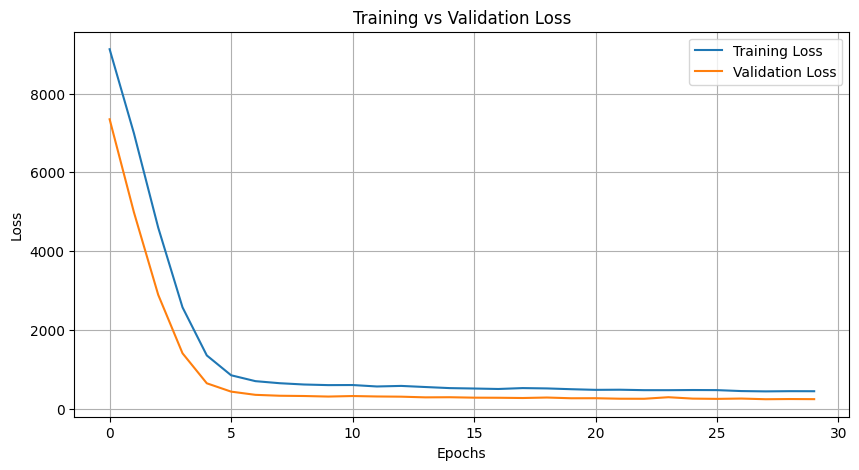

In [37]:
# Extract loss values
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

# Plot losses
plt.figure(figsize=(10,5))
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

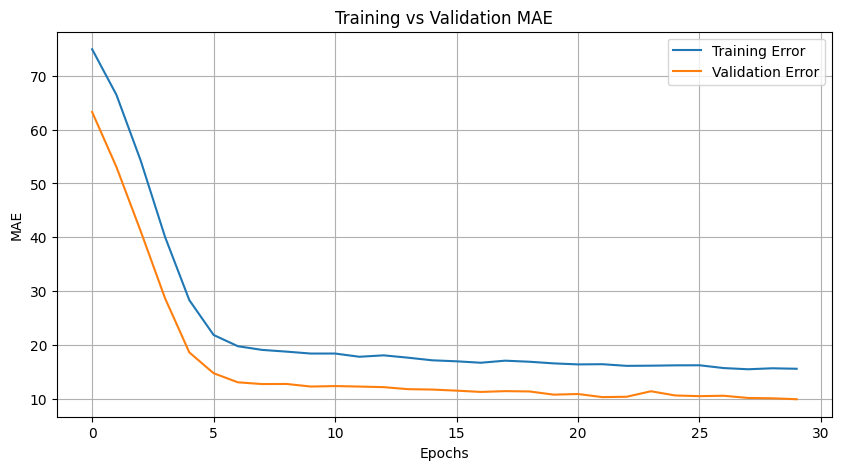

In [38]:
# Extract loss values
train_loss = history.history["mean_absolute_error"]
val_loss = history.history["val_mean_absolute_error"]

# Plot losses
plt.figure(figsize=(10,5))
plt.plot(train_loss, label="Training Error")
plt.plot(val_loss, label="Validation Error")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")
plt.legend()
plt.grid()
plt.show()

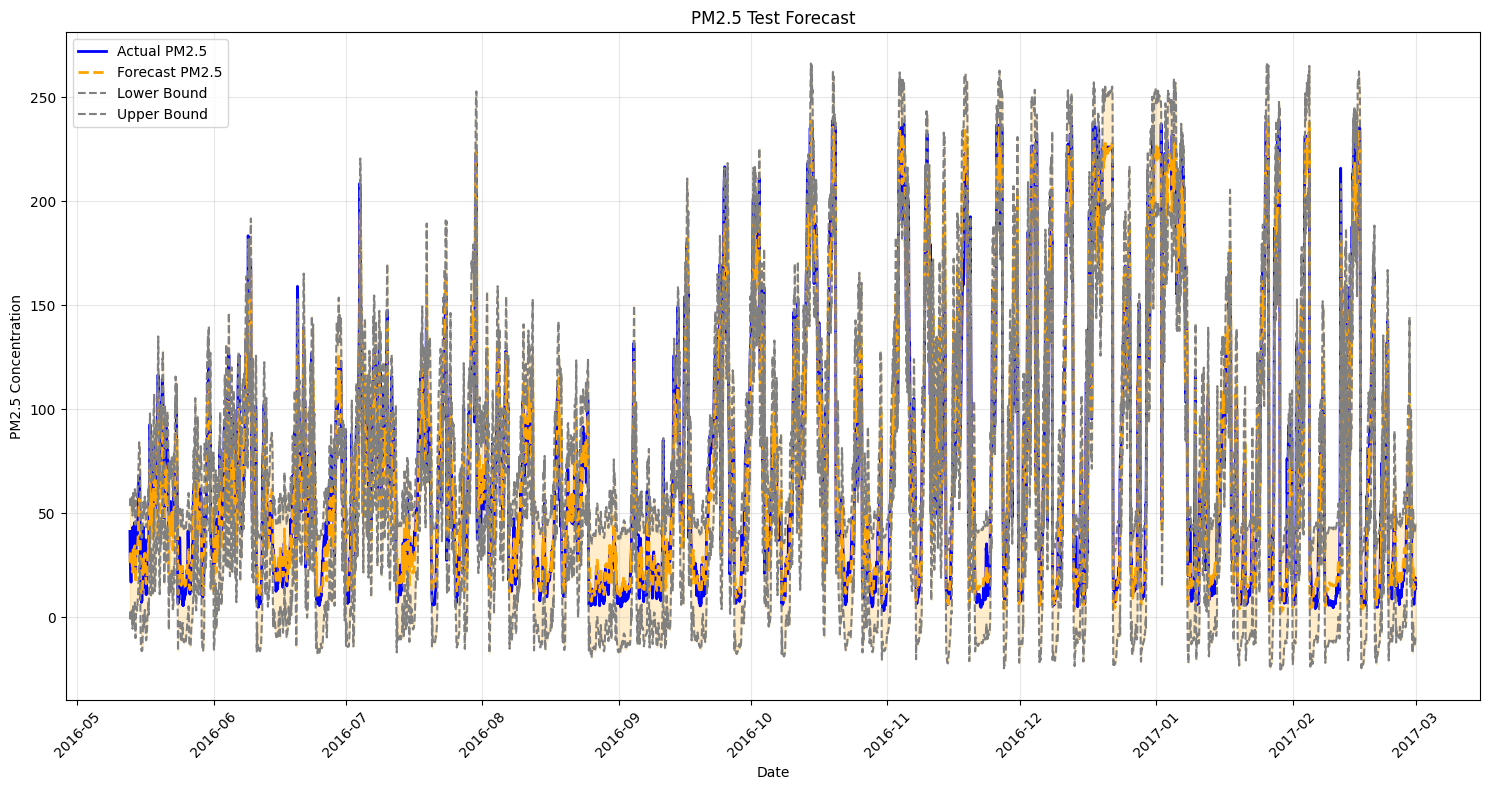

In [39]:
#timeline for test data
timeline_start_idx = WINDOW_SIZE + train_size + val_size
test_timeline = data.index[timeline_start_idx:timeline_start_idx + len(y_test1)]

# confidence bounds
std_error = np.std(y_test1 - test_result.flatten())
lower_bound = test_result.flatten() - 1.96 * std_error
upper_bound = test_result.flatten() + 1.96 * std_error

plt.figure(figsize=(15, 8))

plt.plot(test_timeline, y_test1, label="Actual PM2.5", color="blue", linewidth=2)
plt.plot(test_timeline, test_result.flatten(), label="Forecast PM2.5", color="orange", linewidth=2, linestyle="dashed")
plt.plot(test_timeline, lower_bound, label="Lower Bound", color="gray", linestyle="--")
plt.plot(test_timeline, upper_bound, label="Upper Bound", color="gray", linestyle="--")

plt.fill_between(test_timeline, lower_bound, upper_bound, alpha=0.2, color="orange")

plt.xlabel("Date")
plt.ylabel("PM2.5 Concentration")
plt.title("PM2.5 Test Forecast")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

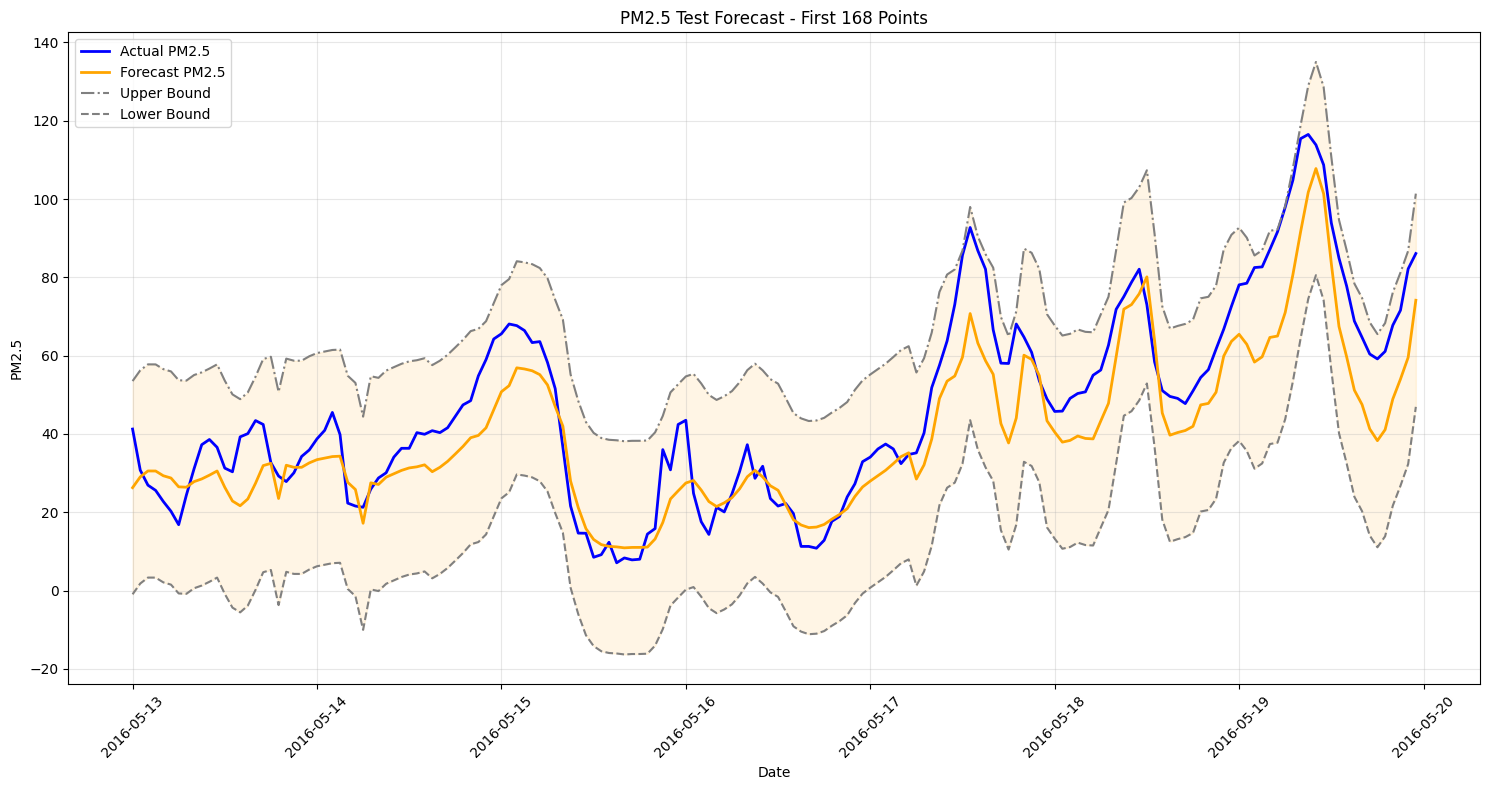

In [40]:
# timeline for test data
timeline_start_idx = WINDOW_SIZE + train_size + val_size
test_timeline = data.index[timeline_start_idx:timeline_start_idx + len(y_test1)]

# confidence bounds
std_error = np.std(y_test1 - test_result.flatten())
lower_bound = test_result.flatten() - 1.96 * std_error
upper_bound = test_result.flatten() + 1.96 * std_error

n_points = 168  # 1 week of hourly data
subset_timeline = test_timeline[:n_points]
subset_actual = y_test1[:n_points]
subset_forecast = test_result.flatten()[:n_points]
subset_lower = lower_bound[:n_points]
subset_upper = upper_bound[:n_points]

plt.figure(figsize=(15, 8))
plt.plot(subset_timeline, subset_actual, label='Actual PM2.5', color='blue', linewidth=2)
plt.plot(subset_timeline, subset_forecast, label='Forecast PM2.5', color='orange', linewidth=2)
plt.plot(subset_timeline, subset_upper, label='Upper Bound', color='gray', linestyle='-.')
plt.plot(subset_timeline, subset_lower, label='Lower Bound', color='gray', linestyle='--')
plt.fill_between(subset_timeline, subset_lower, subset_upper, alpha=0.1, color='orange')

plt.xlabel('Date')
plt.ylabel('PM2.5')
plt.title(f'PM2.5 Test Forecast - First {n_points} Points')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
full_data = data[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN']]

#  feature data  
WINDOW_SIZE = 24  
features = full_data.drop(columns=['PM2.5'])

X_full, _ = new_data_to_X_y(features, full_data['PM2.5'], WINDOW_SIZE)

# Run predictions
aqi_forecast = gru_model.predict(X_full)

1095/1095 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


In [42]:
full_data = full_data.iloc[WINDOW_SIZE:] 
full_data['PM2.5_AQI_forecast'] = aqi_forecast.flatten()

In [43]:
full_data.head()

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,PM2.5_AQI_forecast
datetime,,,,,,,,,,,
2013-03-02 00:00:00,10.833333,13.166667,16.750000,33.250000,524.916667,51.750000,-0.575000,1030.516667,-17.850000,0.0,20.835592
2013-03-02 01:00:00,6.750000,12.250000,14.750000,28.000000,483.333333,56.000000,-1.333333,1030.858333,-17.508333,0.0,20.436701
2013-03-02 02:00:00,8.000000,9.750000,17.625000,31.250000,500.000000,51.250000,-1.691667,1030.491667,-17.366667,0.0,19.727997
2013-03-02 03:00:00,8.333333,14.166667,14.250000,32.916667,575.000000,55.909091,-2.241667,1030.283333,-17.100000,0.0,19.899620
2013-03-02 04:00:00,8.166667,13.750000,15.833333,35.750000,533.333333,46.666667,-2.516667,1030.350000,-17.133333,0.0,20.395376


In [44]:
def get_AQI_bucket(x):
    if x <= 50:
        return "Good"
    elif x <= 100:
        return "Moderate"
    elif x <= 150:
        return "Unhealthy for Sensitive Groups"
    elif x <= 200:
        return "Unhealthy"
    elif x <= 300:
        return "Very Unhealthy"
    elif x > 300:
        return "Hazardous"
    else:
        return np.NaN

In [45]:
# Apply the bucket function
full_data['Actual_PM2.5_Category'] = full_data['PM2.5'].apply(get_AQI_bucket)
full_data['Forecast_PM2.5_AQI_Category'] = full_data['PM2.5_AQI_forecast'].apply(get_AQI_bucket)

In [46]:
full_data.to_excel('AQI_forecast_results.xlsx', index=True)